### Import required library


In [1]:
import pandas as pd
import numpy as np

### Load the Dataset

In [19]:
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

### Explore the Dataset

In [20]:
df.head

<bound method NDFrame.head of         TV      Radio  Social_Media       Sales
0     16.0   6.566231      2.907983   54.732757
1     13.0   9.237765      2.409567   46.677897
2     41.0  15.886446      2.913410  150.177829
3     83.0  30.020028      6.922304  298.246340
4     15.0   8.437408      1.405998   56.594181
...    ...        ...           ...         ...
4567  26.0   4.472360      0.717090   94.685866
4568  71.0  20.610685      6.545573  249.101915
4569  44.0  19.800072      5.096192  163.631457
4570  71.0  17.534640      1.940873  253.610411
4571  42.0  15.966688      5.046548  148.202414

[4572 rows x 4 columns]>

### Check dataset shape

In [21]:
print("Rows and Columns:", df.shape)

Rows and Columns: (4572, 4)


### View column name

In [9]:
print(df.columns)

Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='object')


### Check data types

In [10]:
df.info

<bound method DataFrame.info of         TV      Radio  Social_Media       Sales
0     16.0   6.566231      2.907983   54.732757
1     13.0   9.237765      2.409567   46.677897
2     41.0  15.886446      2.913410  150.177829
3     83.0  30.020028      6.922304  298.246340
4     15.0   8.437408      1.405998   56.594181
...    ...        ...           ...         ...
4567  26.0   4.472360      0.717090   94.685866
4568  71.0  20.610685      6.545573  249.101915
4569  44.0  19.800072      5.096192  163.631457
4570  71.0  17.534640      1.940873  253.610411
4571  42.0  15.966688      5.046548  148.202414

[4572 rows x 4 columns]>

###  Generate summary statistics

In [22]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


### Check for Missing Values

In [23]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [24]:
# To see the total number of missing values:

print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 26


### Handle Missing Values

In [15]:
## df = df.dropna()

Fill missing numerical values with the mean


In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_40412\3010611570.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


### Fill missing categorical values with the mode

In [28]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## Perform exploratory data analysis (EDA) with visualizations

### Import Visualization Libraries

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

### Examine Data Distribution

### Histogram of Numerical Variables

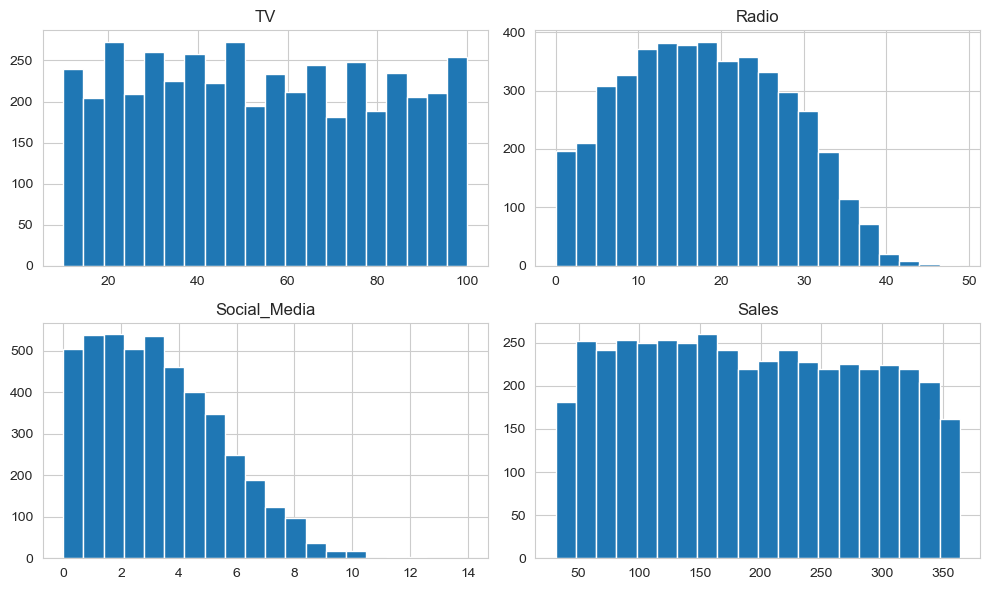

In [30]:
df.hist(figsize=(10, 6), bins=20)
plt.tight_layout()
plt.show()

### Correlation Analysis

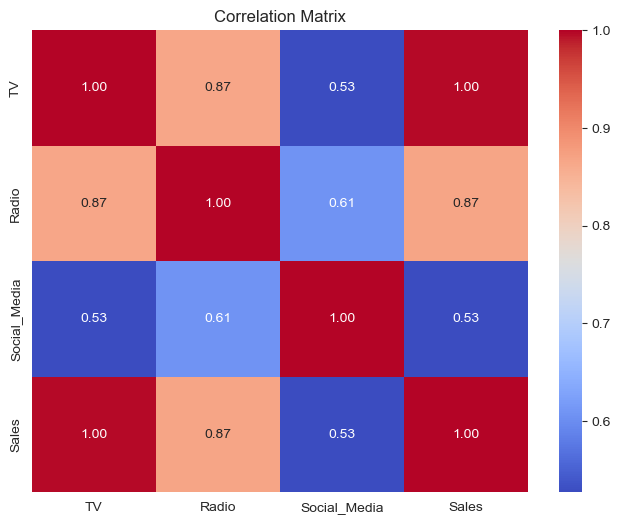

In [31]:
# Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

### Scatter Plot (Most Important)

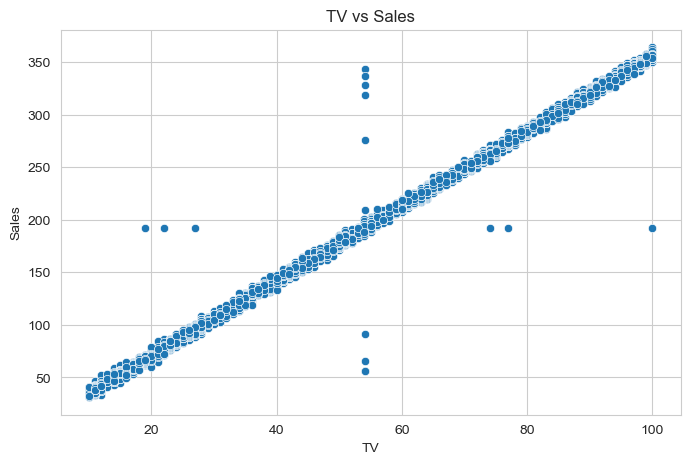

In [33]:
# Visualize the relationship between predictor and target variable.
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='TV',
    y='Sales'
)

plt.title("TV vs Sales")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()


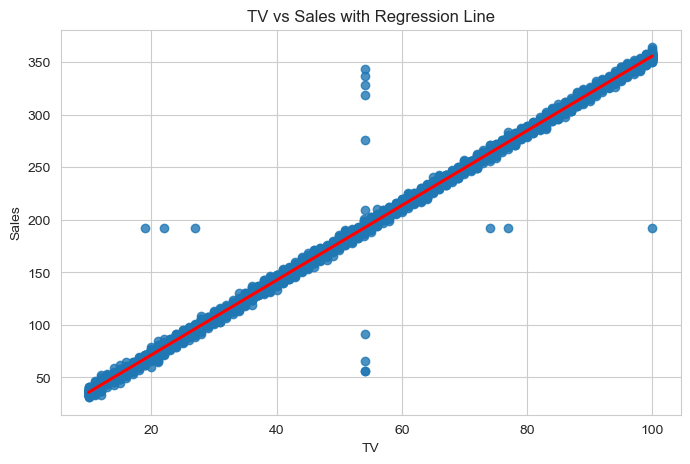

In [35]:
# Add Regression Line

plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x='TV',
    y='Sales',
    line_kws={'color':'red'}
)

plt.title("TV vs Sales with Regression Line")
plt.show()

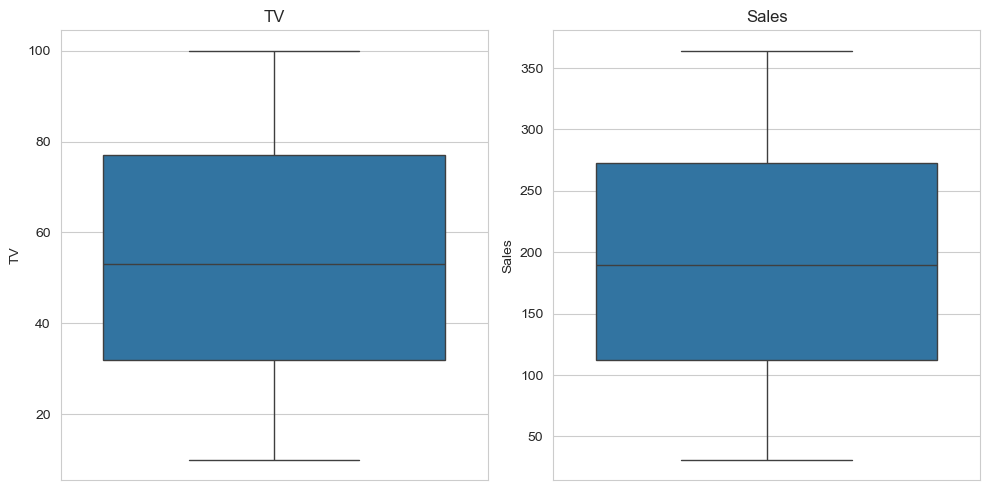

In [38]:
# Boxplots for Outlier Detection

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['TV'])
plt.title("TV")

plt.subplot(1,2,2)
sns.boxplot(y=df['Sales'])
plt.title("Sales")

plt.tight_layout()
plt.show()

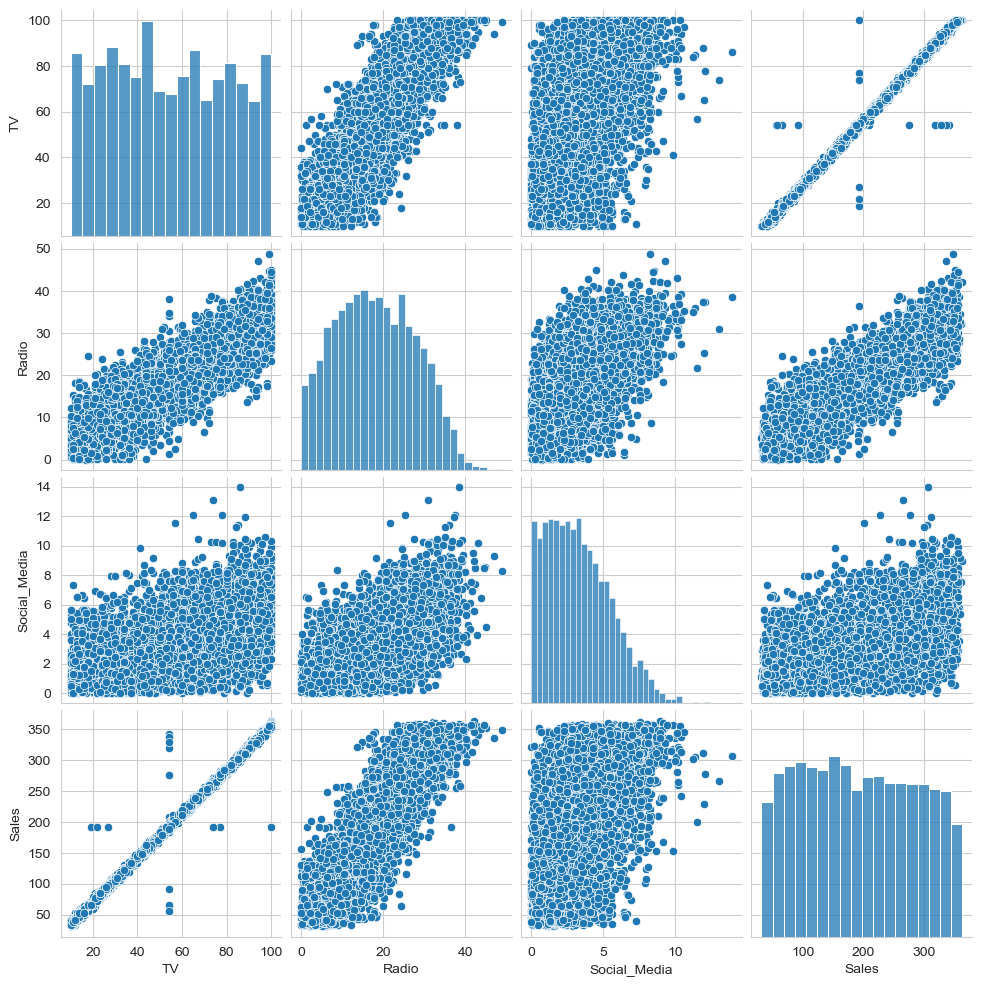

In [39]:
# Pairplot
sns.pairplot(df)
plt.show()

## Identify the independent variable (TV, Radio, or Social Media) most correlated with Sales

### Correlation Matrix

In [40]:
# Select relevant columns
corr_matrix = df[['TV', 'Radio', 'Social_Media', 'Sales']].corr()

print(corr_matrix)

                    TV     Radio  Social_Media     Sales
TV            1.000000  0.866885      0.527010  0.996652
Radio         0.866885  1.000000      0.606793  0.867369
Social_Media  0.527010  0.606793      1.000000  0.528121
Sales         0.996652  0.867369      0.528121  1.000000


### Correlation with Sales Only

In [41]:
correlations = df[['TV', 'Radio', 'Social_Media']].corrwith(df['Sales'])

print(correlations.sort_values(ascending=False))

TV              0.996652
Radio           0.867369
Social_Media    0.528121
dtype: float64


### Visualize the Correlations

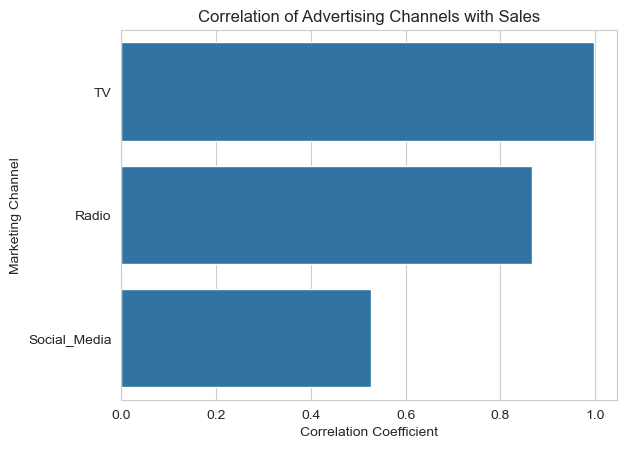

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

correlations = correlations.sort_values(ascending=False)

sns.barplot(
    x=correlations.values,
    y=correlations.index
)

plt.title('Correlation of Advertising Channels with Sales')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Marketing Channel')
plt.show()

### Build an OLS regression model using statsmodels

In [43]:
# Import Required Libraries
import statsmodels.api as sm

In [44]:
# Define X and Y
# Independent variable
X = df['TV']

# Dependent variable
Y = df['Sales']

In [46]:
# Add a Constant (Intercept)

# note :OLS requires an intercept term.

X = sm.add_constant(X)

In [47]:
# Build the OLS Model
model = sm.OLS(Y, X).fit()

In [48]:
# View the Regression Results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.792e+05
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:14:36   Log-Likelihood:                -15765.
No. Observations:                4572   AIC:                         3.153e+04
Df Residuals:                    4570   BIC:                         3.155e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2849      0.259      1.100      0.2

In [49]:
#Make Predictions
predictions = model.predict(X)

print(predictions.head())

0     57.157216
1     46.493657
2    146.020205
3    295.310026
4     53.602696
dtype: float64


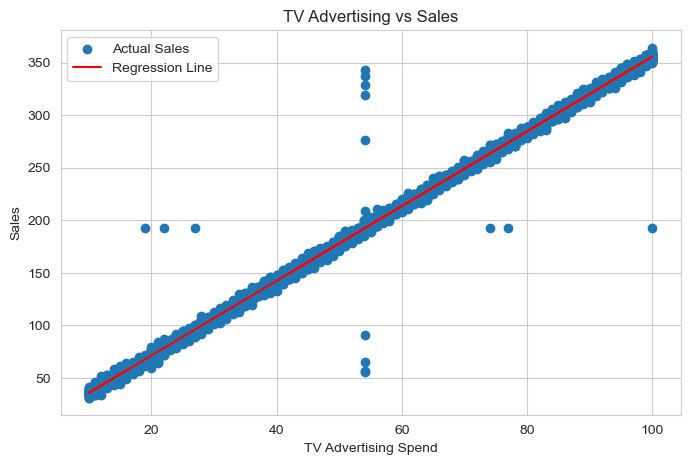

In [50]:
#Plot Actual vs Predicted Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['TV'], df['Sales'], label='Actual Sales')
plt.plot(df['TV'], predictions, color='red', label='Regression Line')

plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('TV Advertising vs Sales')
plt.legend()
plt.show()

### Diagnostic Plots for Linearity, Normality, and Homoscedasticity

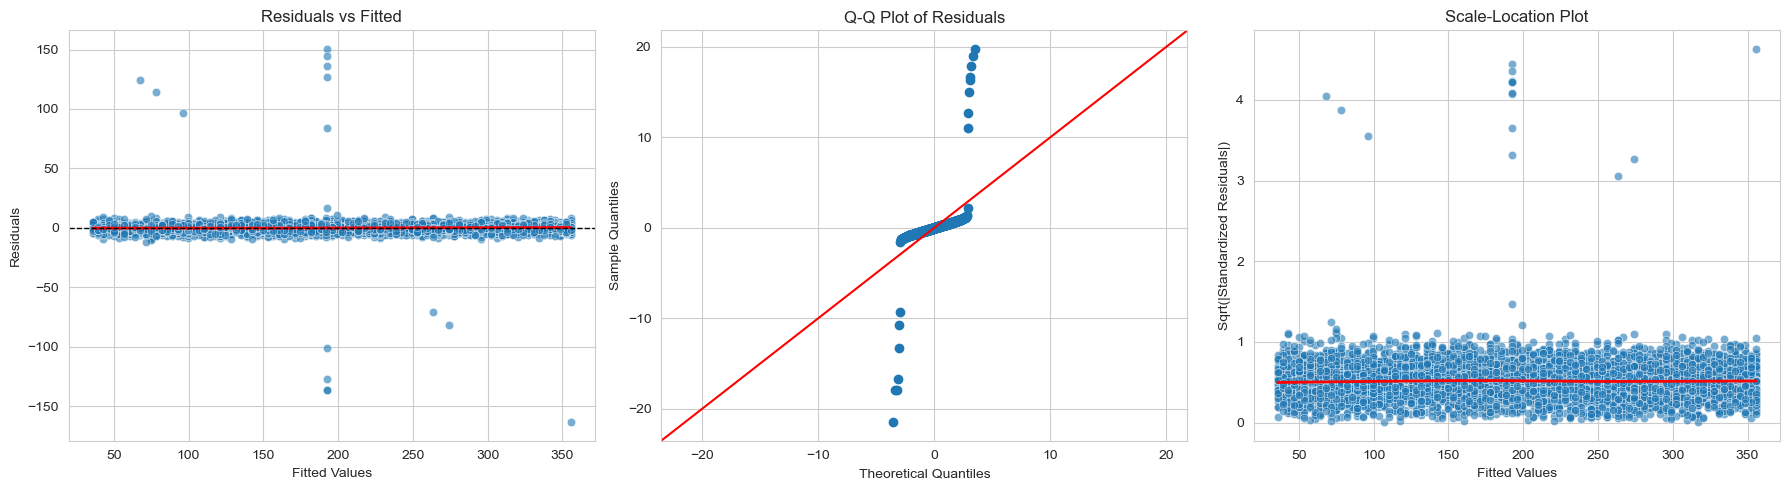

In [51]:
# Create diagnostic plots from the fitted OLS model
residuals = model.resid
fitted_values = model.fittedvalues
standardized_residuals = residuals / residuals.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Linearity: residuals should be randomly scattered around zero
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.6)
sns.regplot(x=fitted_values, y=residuals, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 2}, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# 2. Normality: points should roughly follow the 45-degree line
sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# 3. Homoscedasticity: spread should be fairly constant across fitted values
sns.scatterplot(x=fitted_values, y=np.sqrt(np.abs(standardized_residuals)),
                ax=axes[2], alpha=0.6)
sns.regplot(x=fitted_values, y=np.sqrt(np.abs(standardized_residuals)),
            scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 2}, ax=axes[2])
axes[2].set_title('Scale-Location Plot')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Sqrt(|Standardized Residuals|)')

plt.tight_layout()
plt.show()

## Interpret R-squared, coefficients, and p-values in business context


#### This model shows that TV advertising has a strong and statistically significant positive relationship with sales. The model explains 99.3% of sales variation, and each additional unit of TV spend is associated with an estimated 3.55-unit increase in sales.

##  Formulate a clear ROI-based recommendation for marketing budget allocation

#### Based on the regression results, the company should prioritize TV advertising when allocating marketing budget. The very high R-squared (0.993) and statistically significant TV coefficient suggest that TV spend is a powerful driver of sales. Therefore, increasing investment in TV is likely to generate the greatest sales return compared with a uniform or random budget split.